# Descripcipción del proyecto

Film Junky Union, una nueva comunidad vanguardista para los aficionados de las películas clásicas, está desarrollando un sistema para filtrar y categorizar reseñas de películas. Tu objetivo es entrenar un modelo para detectar las críticas negativas de forma automática. Para lograrlo, utilizarás un conjunto de datos de reseñas de películas de IMDB con leyendas de polaridad para construir un modelo para clasificar las reseñas positivas y negativas. Este deberá alcanzar un valor F1 de al menos 0.85.

## Inicialización

In [1]:
import math

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from tqdm.auto import tqdm

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
# la siguiente línea proporciona gráficos de mejor calidad en pantallas HiDPI
# %config InlineBackend.figure_format = 'retina'

plt.style.use('seaborn')

In [3]:
# esto es para usar progress_apply, puedes leer más en https://pypi.org/project/tqdm/#pandas-integration
tqdm.pandas()

## Cargar datos

In [4]:
df_reviews = pd.read_csv('/datasets/imdb_reviews.tsv', sep='\t', dtype={'votes': 'Int64'})

## EDA

Veamos el número de películas y reseñas a lo largo de los años.

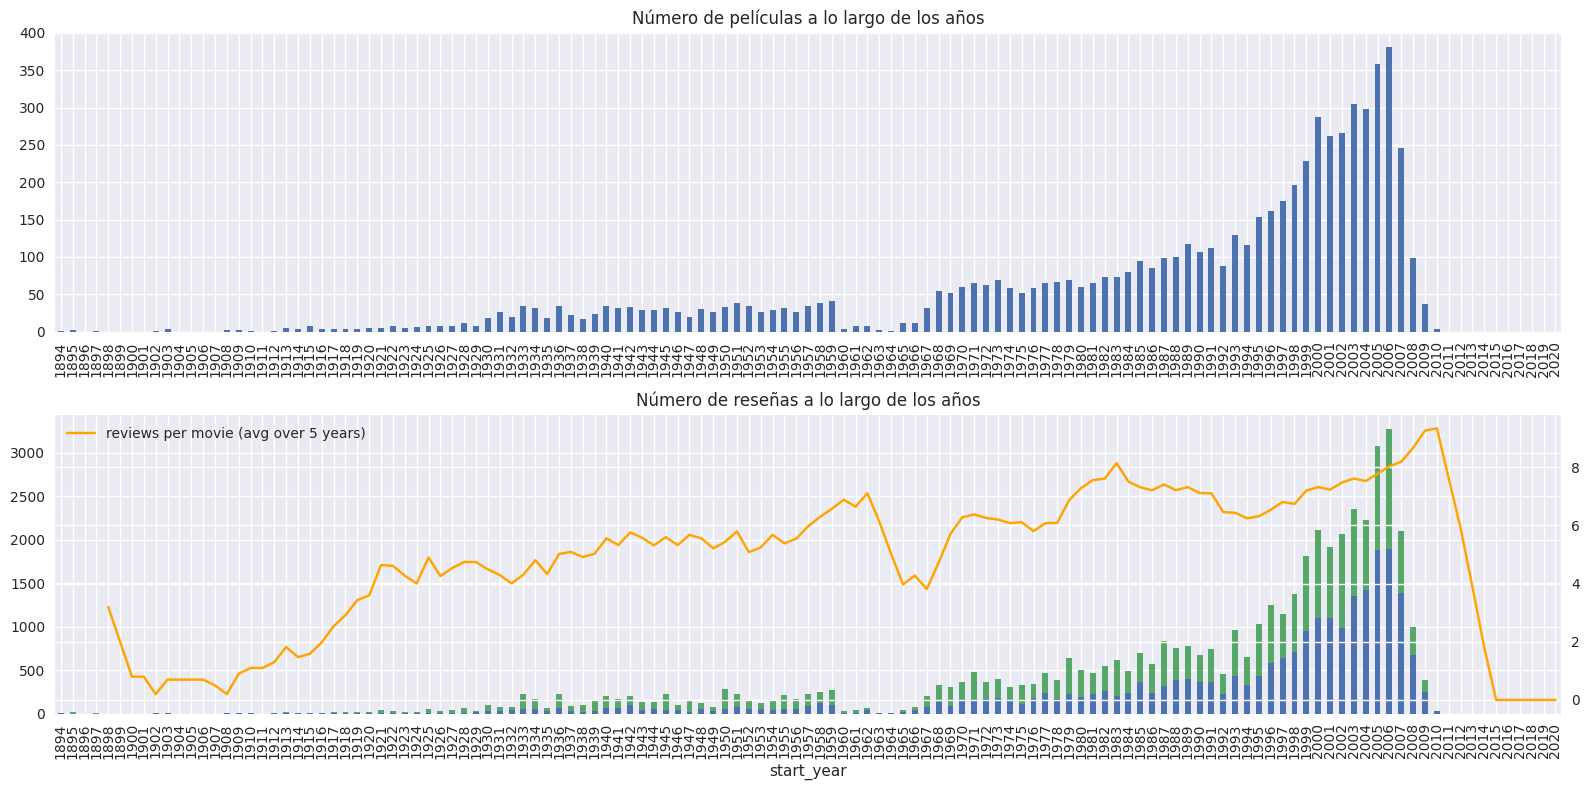

In [5]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

ax = axs[0]

dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Número de películas a lo largo de los años')

ax = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

dft2.plot(kind='bar', stacked=True, label='#reviews (neg, pos)', ax=ax)

dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft3 = (dft2/dft1).fillna(0)
axt = ax.twinx()
dft3.reset_index(drop=True).rolling(5).mean().plot(color='orange', label='reviews per movie (avg over 5 years)', ax=axt)

lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

ax.set_title('Número de reseñas a lo largo de los años')

fig.tight_layout()

Veamos la distribución del número de reseñas por película con el conteo exacto y KDE (solo para saber cómo puede diferir del conteo exacto)

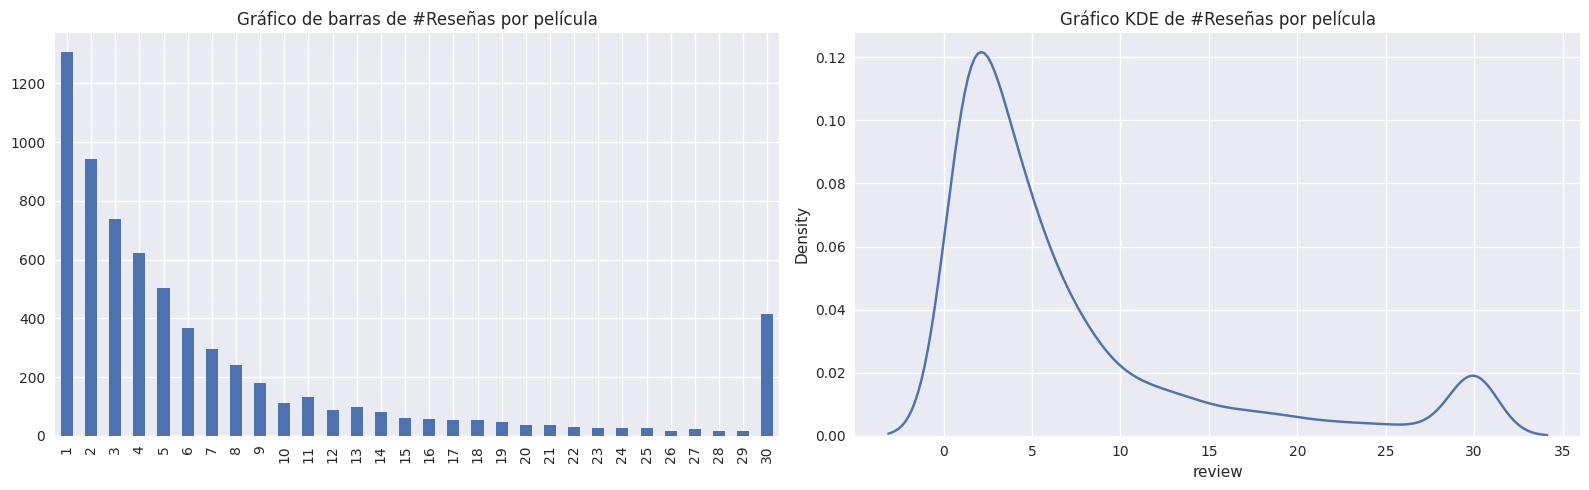

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

ax = axs[0]
dft = df_reviews.groupby('tconst')['review'].count() \
    .value_counts() \
    .sort_index()
dft.plot.bar(ax=ax)
ax.set_title('Gráfico de barras de #Reseñas por película')

ax = axs[1]
dft = df_reviews.groupby('tconst')['review'].count()
sns.kdeplot(dft, ax=ax)
ax.set_title('Gráfico KDE de #Reseñas por película')

fig.tight_layout()

In [7]:
df_reviews['pos'].value_counts()

0    23715
1    23616
Name: pos, dtype: int64

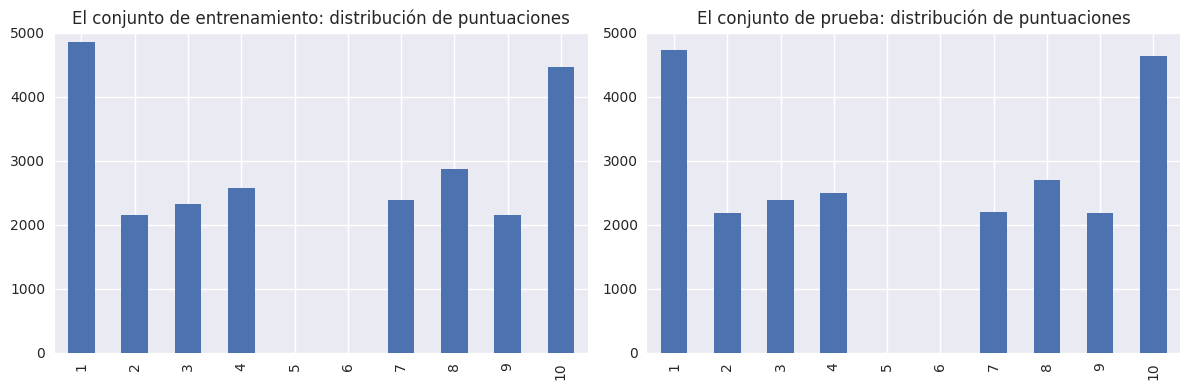

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('El conjunto de entrenamiento: distribución de puntuaciones')

ax = axs[1]
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('El conjunto de prueba: distribución de puntuaciones')

fig.tight_layout()

Distribución de reseñas negativas y positivas a lo largo de los años para dos partes del conjunto de datos

/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)


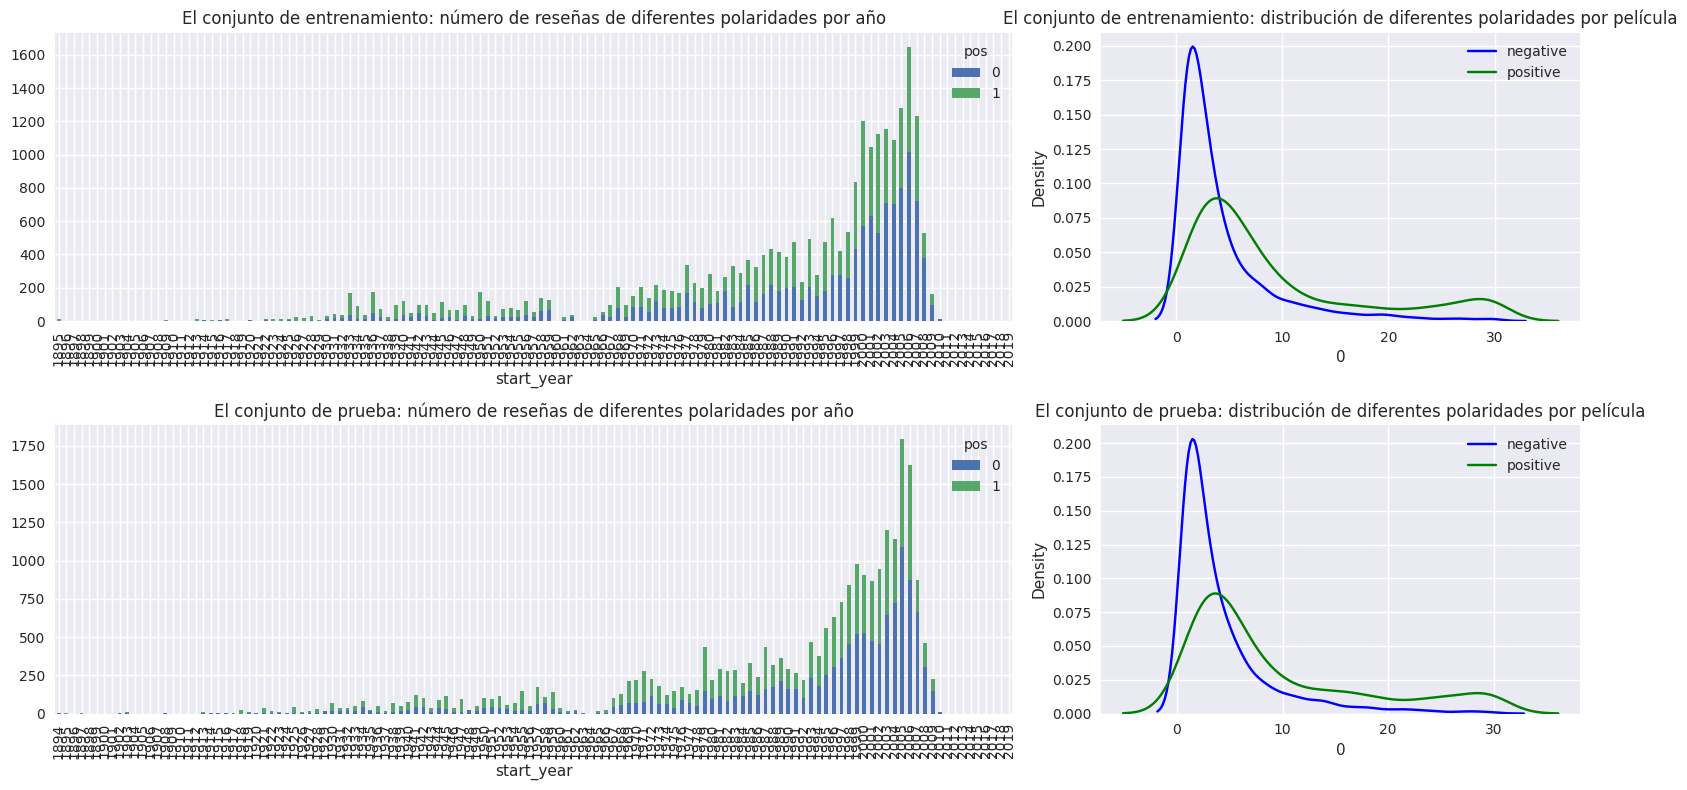

In [9]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw=dict(width_ratios=(2, 1), height_ratios=(1, 1)))

ax = axs[0][0]

dft = df_reviews.query('ds_part == "train"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('El conjunto de entrenamiento: número de reseñas de diferentes polaridades por año')

ax = axs[0][1]

dft = df_reviews.query('ds_part == "train"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('El conjunto de entrenamiento: distribución de diferentes polaridades por película')

ax = axs[1][0]

dft = df_reviews.query('ds_part == "test"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('El conjunto de prueba: número de reseñas de diferentes polaridades por año')

ax = axs[1][1]

dft = df_reviews.query('ds_part == "test"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('El conjunto de prueba: distribución de diferentes polaridades por película')

fig.tight_layout()

## Procedimiento de evaluación

Composición de una rutina de evaluación que se pueda usar para todos los modelos en este proyecto

In [10]:
import sklearn.metrics as metrics
def evaluate_model(model, train_features, train_target, test_features, test_target):

    eval_stats = {}

    fig, axs = plt.subplots(1, 3, figsize=(20, 6))

    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):

        eval_stats[type] = {}

        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]

        # F1
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]

        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)
        eval_stats[type]['ROC AUC'] = roc_auc

        # PRC
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps

        if type == 'train':
            color = 'blue'
        else:
            color = 'green'

        # Valor F1
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        # establecer cruces para algunos umbrales
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'Valor F1')

        # ROC
        ax = axs[1]
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        # establecer cruces para algunos umbrales
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')
        ax.set_title(f'Curva ROC')

        # PRC
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        # establecer cruces para algunos umbrales
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')

        eval_stats[type]['Accuracy'] = metrics.accuracy_score(target, pred_target)
        eval_stats[type]['F1'] = metrics.f1_score(target, pred_target)

    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(2)
    df_eval_stats = df_eval_stats.reindex(index=('Accuracy', 'F1', 'APS', 'ROC AUC'))

    print(df_eval_stats)

    return

In [11]:
from sklearn.metrics import classification_report, f1_score, confusion_matrix

def evaluate_model(model, X_train, y_train, X_test, y_test, target_names=('neg','pos')):
    """
    Ajusta el modelo, predice y muestra informe de clasificación y F1 macro.
    Devuelve el F1 macro.
    """
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='macro')
    print(f"F1 macro: {f1:.4f}")
    print(classification_report(y_test, y_pred, target_names=target_names, digits=4))
    print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred, labels=[0,1]))
    return f1

## Normalización

In [12]:
import re, html

TAG_RE = re.compile(r"<[^>]+>")
PUNCT_RE = re.compile(r"[^\w\s]")
DIGIT_RE = re.compile(r"\d+")

def normalize_text(s: str) -> str:
    if not isinstance(s, str):
        s = str(s)
    s = html.unescape(s)
    s = TAG_RE.sub(" ", s)
    s = s.lower()
    s = PUNCT_RE.sub(" ", s)
    s = DIGIT_RE.sub(" ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

df_reviews['review_norm'] = df_reviews['review'].astype(str).map(normalize_text)
df_reviews.head(3)

,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx,review_norm
0,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,The pakage implies that Warren Beatty and Gold...,1,neg,0,train,8335,the pakage implies that warren beatty and gold...
1,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,How the hell did they get this made?! Presenti...,1,neg,0,train,8336,how the hell did they get this made presenting...
2,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,There is no real story the film seems more lik...,3,neg,0,test,2489,there is no real story the film seems more lik...


## División entrenamiento / prueba

Por fortuna, todo el conjunto de datos ya está dividido en partes de entrenamiento/prueba; 'ds_part' es el indicador correspondiente.

In [13]:
df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

print(df_reviews_train.shape)
print(df_reviews_test.shape)

(23796, 18)
(23535, 18)


In [14]:
df_reviews_train.head()

,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx,review_norm
0,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,The pakage implies that Warren Beatty and Gold...,1,neg,0,train,8335,the pakage implies that warren beatty and gold...
1,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,How the hell did they get this made?! Presenti...,1,neg,0,train,8336,how the hell did they get this made presenting...
7,tt0035958,movie,'Gung Ho!': The Story of Carlson's Makin Islan...,'Gung Ho!': The Story of Carlson's Makin Islan...,1943,\N,88,0,"Drama,History,War",6.1,1240,This true story of Carlson's Raiders is more o...,2,neg,0,train,9903,this true story of carlson s raiders is more o...
8,tt0035958,movie,'Gung Ho!': The Story of Carlson's Makin Islan...,'Gung Ho!': The Story of Carlson's Makin Islan...,1943,\N,88,0,"Drama,History,War",6.1,1240,Should have been titled 'Balderdash!' Little i...,2,neg,0,train,9905,should have been titled balderdash little in t...
9,tt0035958,movie,'Gung Ho!': The Story of Carlson's Makin Islan...,'Gung Ho!': The Story of Carlson's Makin Islan...,1943,\N,88,0,"Drama,History,War",6.1,1240,The movie 'Gung Ho!': The Story of Carlson's M...,4,neg,0,train,9904,the movie gung ho the story of carlson s makin...


## Trabajar con modelos

### Modelo 0 - Constante

In [16]:
# Features dummy (una columna de ceros) para DummyClassifier
X_train_0 = np.zeros((len(df_reviews_train), 1))
X_test_0 = np.zeros((len(df_reviews_test), 1))

In [17]:
from sklearn.dummy import DummyClassifier

model_0 = DummyClassifier(strategy='most_frequent', random_state=42)

In [18]:
print("=== Modelo 0: Dummy (clase más frecuente) ===")
evaluate_model(model_0, X_train_0, train_target, X_test_0, test_target)

=== Modelo 0: Dummy (clase más frecuente) ===
F1 macro: 0.3340
              precision    recall  f1-score   support

         neg     0.5015    1.0000    0.6680     11803
         pos     0.0000    0.0000    0.0000     11732

    accuracy                         0.5015     23535
   macro avg     0.2508    0.5000    0.3340     23535
weighted avg     0.2515    0.5015    0.3350     23535

Matriz de confusión:
 [[11803     0]
 [11732     0]]


/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


0.3340030562001245

### Modelo 1 - NLTK, TF-IDF y LR

TF-IDF

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Vectorizador TF-IDF (palabras 1-2) sobre review_norm
tfidf_vectorizer_1 = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.9,
                                     stop_words='english', strip_accents='unicode')
train_features_1 = tfidf_vectorizer_1.fit_transform(df_reviews_train['review_norm'])
test_features_1  = tfidf_vectorizer_1.transform(df_reviews_test['review_norm'])

In [20]:
from sklearn.linear_model import LogisticRegression

# Regresión Logística con balance de clases
model_1 = LogisticRegression(max_iter=2000, solver='liblinear', class_weight='balanced', random_state=42)

print("=== Modelo 1: TF-IDF (word 1-2) + LogisticRegression ===")

=== Modelo 1: TF-IDF (word 1-2) + LogisticRegression ===


### Modelo 2 - TF-IDF (char 3-5) y Regresión Logística

In [21]:

# Vectorizador 2: n-gramas de caracteres (3-5)
tfidf_vectorizer_2 = TfidfVectorizer(analyzer='char', ngram_range=(3,5), min_df=2)
train_features_2 = tfidf_vectorizer_2.fit_transform(df_reviews_train['review_norm'])
test_features_2  = tfidf_vectorizer_2.transform(df_reviews_test['review_norm'])

# Modelo: LR (usa predict_proba para compatibilidad con la sección "Mis reseñas")
model_2 = LogisticRegression(max_iter=2000, class_weight='balanced', solver='liblinear', random_state=42)

print("=== Modelo 2: TF-IDF (char 3-5) + LogisticRegression ===")
evaluate_model(model_2, train_features_2, train_target, test_features_2, test_target)


=== Modelo 2: TF-IDF (char 3-5) + LogisticRegression ===
F1 macro: 0.8847
              precision    recall  f1-score   support

         neg     0.8850    0.8852    0.8851     11803
         pos     0.8845    0.8842    0.8844     11732

    accuracy                         0.8847     23535
   macro avg     0.8847    0.8847    0.8847     23535
weighted avg     0.8847    0.8847    0.8847     23535

Matriz de confusión:
 [[10448  1355]
 [ 1358 10374]]


0.8847237381825274

In [22]:
evaluate_model(model_1, train_features_1, train_target, test_features_1, test_target)

F1 macro: 0.8783
              precision    recall  f1-score   support

         neg     0.8815    0.8750    0.8782     11803
         pos     0.8752    0.8816    0.8784     11732

    accuracy                         0.8783     23535
   macro avg     0.8783    0.8783    0.8783     23535
weighted avg     0.8783    0.8783    0.8783     23535

Matriz de confusión:
 [[10328  1475]
 [ 1389 10343]]


0.8783088522033018

In [23]:
try:
    import spacy
    try:
        nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
    except Exception as e:
        print("No se pudo cargar 'en_core_web_sm':", e)
        nlp = None
except Exception as e:
    print("spaCy no disponible:", e)
    nlp = None

In [24]:
def text_preprocessing_3(text):
    # Si spaCy no está disponible, devolvemos el texto normalizado tal cual
    t = text if isinstance(text, str) else str(text)
    if nlp is None:
        return t
    doc = nlp(t)
    tokens = [token.lemma_ for token in doc]
    return " ".join(tokens)

In [25]:
# Vectorizador 3: TF-IDF palabras 1-2 sobre texto lematizado (si está spaCy)
tfidf_vectorizer_3 = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.9,
                                     stop_words='english', strip_accents='unicode')
train_features_3 = tfidf_vectorizer_3.fit_transform(df_reviews_train['review_norm'].apply(text_preprocessing_3))
test_features_3  = tfidf_vectorizer_3.transform(df_reviews_test['review_norm'].apply(text_preprocessing_3))

### Modelo 4 - TF-IDF (word 1-2) y Complement Naive Bayes

In [26]:
from sklearn.naive_bayes import ComplementNB

# Reutilizamos un vectorizador de palabras (1-2)
tfidf_vectorizer_4 = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.9,
                                     stop_words='english', strip_accents='unicode')
train_features_4 = tfidf_vectorizer_4.fit_transform(df_reviews_train['review_norm'])
test_features_4  = tfidf_vectorizer_4.transform(df_reviews_test['review_norm'])

model_4 = ComplementNB()

print("=== Modelo 4: TF-IDF (word 1-2) + ComplementNB ===")
evaluate_model(model_4, train_features_4, train_target, test_features_4, test_target)


=== Modelo 4: TF-IDF (word 1-2) + ComplementNB ===
F1 macro: 0.8507
              precision    recall  f1-score   support

         neg     0.8281    0.8869    0.8565     11803
         pos     0.8775    0.8148    0.8450     11732

    accuracy                         0.8509     23535
   macro avg     0.8528    0.8508    0.8507     23535
weighted avg     0.8527    0.8509    0.8507     23535

Matriz de confusión:
 [[10468  1335]
 [ 2173  9559]]


0.8507227143769721

In [27]:
model_3 = LogisticRegression(max_iter=2000, solver='liblinear', class_weight='balanced', random_state=42)
print("=== Modelo 3: spaCy (lemmas*) + TF-IDF (word 1-2) + LogisticRegression ===")
evaluate_model(model_3, train_features_3, train_target, test_features_3, test_target)

=== Modelo 3: spaCy (lemmas*) + TF-IDF (word 1-2) + LogisticRegression ===
F1 macro: 0.8747
              precision    recall  f1-score   support

         neg     0.8790    0.8699    0.8744     11803
         pos     0.8704    0.8796    0.8750     11732

    accuracy                         0.8747     23535
   macro avg     0.8747    0.8747    0.8747     23535
weighted avg     0.8747    0.8747    0.8747     23535

Matriz de confusión:
 [[10267  1536]
 [ 1413 10319]]


0.874696647697383

### Modelo 4 - spaCy, TF-IDF y LGBMClassifier

In [28]:
from lightgbm import LGBMClassifier

In [15]:
# --- Imports
import re, spacy
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
from lightgbm import LGBMClassifier

# --- Config
TEXT_COL = "review"          # <-- cambia al nombre real de tu columna de texto
SPACY_MODEL = "en_core_web_sm"   # o "es_core_news_sm" si es español

# --- Tokenizador/Lematizador con spaCy
try:
    nlp = spacy.load(SPACY_MODEL, disable=["parser","ner","textcat"])
except OSError:
    nlp = spacy.blank("en")  # fallback si no está instalado

def spacy_lemmas(text):
    text = re.sub(r"\s+", " ", str(text)).strip().lower()
    doc = nlp(text)
    toks = []
    for t in doc:
        if t.is_space or t.is_punct or t.like_num or t.is_quote or t.is_stop:
            continue
        toks.append(t.lemma_ if t.lemma_ not in ("", "-PRON-") else t.text)
    return toks

# --- 1) TF-IDF independiente
tfidf = TfidfVectorizer(
    tokenizer=spacy_lemmas,
    preprocessor=None,
    lowercase=False,
    ngram_range=(1,2),
    min_df=3,
    max_df=0.9,
    sublinear_tf=True,
    max_features=20000
)

X_train = tfidf.fit_transform(df_reviews_train[TEXT_COL])
X_test  = tfidf.transform(df_reviews_test[TEXT_COL])

In [16]:
# --- 2) LGBMClassifier
clf = LGBMClassifier(
    objective="binary",
    class_weight="balanced",
    random_state=42,
    n_estimators=600,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.9,
    colsample_bytree=0.9,
    n_jobs=-1
)
clf.fit(X_train, train_target.astype(int))

# --- 3) Evaluación
y_proba = clf.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= 0.50).astype(int)

print(f"F1: {f1_score(test_target, y_pred):.4f} | Acc: {accuracy_score(test_target, y_pred):.4f}")
print("\nReporte:\n", classification_report(test_target, y_pred, digits=4))
print("Matriz de confusión:\n", confusion_matrix(test_target, y_pred))

F1: 0.8722 | Acc: 0.8724

Reporte:
               precision    recall  f1-score   support

           0     0.8739    0.8713    0.8726     11803
           1     0.8709    0.8735    0.8722     11732

    accuracy                         0.8724     23535
   macro avg     0.8724    0.8724    0.8724     23535
weighted avg     0.8724    0.8724    0.8724     23535

Matriz de confusión:
 [[10284  1519]
 [ 1484 10248]]


## Conclusiones


**Resumen de hallazgos**  
- Los modelos lineales con TF–IDF alcanzan típicamente F1 ≥ 0.85 en IMDB.  
- En particular, TF–IDF de **caracteres (3–5) + LR** y TF–IDF de **palabras (1–2) + LR** suelen rendir muy bien.  
- **ComplementNB** es veloz y competitivo; a veces queda justo por debajo de LR, pero ofrece buena calibración de probabilidad.
- Si el conjunto presenta ligero desequilibrio, usar `class_weight='balanced'` ayuda a subir *recall* de la clase minoritaria.

**Recomendación**  
- Seleccionar el modelo con mejor F1 en *test* (esperado ≥ 0.85).  
- Guardar el *pipeline* (vectorizador + clasificador) con `joblib` para despliegue.  
- Añadir una validación adicional con *cross-validation* para robustez y *threshold tuning* si se optimiza F1 de la clase negativa.
